# Random Forest Model — Low / High / All MP Datasets
Follows the same workflow as `model_development.ipynb` (LightGBM reference).
Feature selection uses RF-RFE; HPO uses BayesSearchCV (20 trials) + default trial 0.

In [1]:
import pandas as pd
import numpy as np
import pickle
from pathlib import Path

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from skopt import BayesSearchCV
from skopt.space import Real, Integer
import joblib
import matplotlib.pyplot as plt

import feature_engineering_helper as hf

## 0. Configuration

In [2]:
### change to 1 for quick test, 0 for full run
quick_test = 0
### change to 1 for quick test, 0 for full run

if quick_test == 1:
    n_features_to_select = 40
    step                 = 50
    print('Quick test mode')
else:
    n_features_to_select = 1
    step                 = 5
    print('Full run mode')

data_prefix   = '../0_data/processed_data/'
figure_prefix = '../Figures/'

model_types = ['RF']
label       = 'MP_label'
non_feature_cols = ['SMILES', 'MP', 'Type'] + [label]
data_types  = ['L', 'H', 'All']

# MP threshold — consistent across all models in this project
MP_THRESHOLD = 250   # °C boundary between Low ('L') and High ('H')

Full run mode


## 1. Feature Selection (RFE with RF)

In [3]:
if quick_test == 1:
    df_all_feature        = pd.read_parquet(data_prefix + 'data_with_all_features_scaled.parquet').head(500)
    df_all_feature_scaled = df_all_feature
else:
    df_all_feature        = pd.read_parquet(data_prefix + 'data_with_all_features.parquet')
    df_all_feature_scaled = pd.read_parquet(data_prefix + 'data_with_all_features_scaled.parquet')

df_all_feature

,MACCS_0,MACCS_1,MACCS_10,MACCS_100,MACCS_101,MACCS_102,MACCS_103,MACCS_104,MACCS_105,MACCS_106,...,RDKit_fr_term_acetylene,RDKit_fr_tetrazole,RDKit_fr_thiazole,RDKit_fr_thiocyan,RDKit_fr_thiophene,RDKit_fr_unbrch_alkane,RDKit_fr_urea,RDKit_qed,SMILES,Type
0,0,0,0,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0.399047,COc1ccc(cc1)C1(C)CCc2c(-c3c1cc(o3)C)c1c(o2)ccc...,Train
1,0,0,0,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0.497846,C[C@H]1[C@@H]2CC[C@@H]3[C@](C1=O)(C2)C(=O)OC[C...,Train
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.667560,Cc1cc(Br)c(cc1Br)C,Train
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.669548,OC(=O)c1ccc(c(c1)F)C,Train
4,0,0,0,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0.703933,OC(=O)C1CC(=O)c2c1cccc2,Train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17215,0,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0.438791,CN(CCNCc1cc(ccc1O)[N+](=O)[O-])C,Test
17216,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.490747,C[Si](C#Cc1ccc(cc1)C#C[Si](C)(C)C)(C)C,Test
17217,0,0,0,0,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0.579542,Brc1ccc(c(c1)C(F)(F)F)[N+](=O)[O-],Test
17218,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.701361,OC(=O)C(C(=O)O)Cc1ccccc1,Test


In [4]:
def feature_engineering_workflow(model_type, df):
    data      = df.copy()
    tolerance = 0.01

    all_feature_cols = data.drop(columns=non_feature_cols, errors='ignore').columns.tolist()
    print(f'Total number of features: {len(all_feature_cols)}')
    print()

    # Variance filter
    variance_threshold = 0.01
    print(f'Variance threshold feature selection: variance_threshold={variance_threshold}')
    df_X_variance = hf.reduce_features_by_variance(data[all_feature_cols],
                                                    variance_threshold=variance_threshold)
    print()

    # RFE
    print(f'RFE feature selection: model={model_type}, tolerance={tolerance}, '
          f'n_features_to_select={n_features_to_select}, step={step}')
    RFE_results = hf.reduce_features_by_RFE(
        df_X_variance, data['MP'],
        model=model_type, tolerance=tolerance,
        n_features_to_select=n_features_to_select, step=step,
        metric='rmse', cv_strategy=None
    )
    print()

    hf.RFE_plot(RFE_results, tolerance, model_type,
                save_path=figure_prefix + f'RFE_plot_{model_type}.png')

    return df_X_variance, RFE_results, df_X_variance[RFE_results['best_features']]

Running feature engineering workflow with RF model on L data
Number of samples: 11439, Number of features: 388
Total number of features: 384

Variance threshold feature selection: variance_threshold=0.01
Original features: 384
Removed features: 50
Remaining features: 334

RFE feature selection: model=RF, tolerance=0.01, n_features_to_select=1, step=5


RFE Feature Selection:   1%|▏         | 1/67 iteration

Iteration 0/67 | Features: 329 | RMSE: 35.0995 ± 1.0381 | Removed: [MACCS_18, MACCS_32, MACCS_55, MACCS_61, RDKit_EState_VSA11]


RFE Feature Selection:  16%|█▋        | 11/67 iteration

Iteration 10/67 | Features: 279 | RMSE: 35.1259 ± 1.0541 | Removed: [MACCS_134, MACCS_159, MACCS_59, RDKit_fr_lactone, RDKit_fr_oxime]


...

Iteration 50/67 | Features: 79 | RMSE: 35.2682 ± 1.1117 | Removed: [MACCS_101, RDKit_Chi0v, RDKit_Chi2n, RDKit_Chi3n, RDKit_EState_VSA9]


RFE Feature Selection:  91%|█████████ | 61/67 iteration

Iteration 60/67 | Features: 29 | RMSE: 35.5454 ± 1.0884 | Removed: [RDKit_BCUT2D_CHGLO, RDKit_MaxEStateIndex, RDKit_NumRotatableBonds, RDKit_PEOE_VSA8, RDKit_Phi]


RFE Feature Selection: 100%|██████████| 67/67 iteration



Global best RMSE: 35.0652
Threshold (1.0% tolerance): 35.4158

✓ RFE Feature Selection Complete (Parsimonious)
  Selected number of features: 39
  Selected RMSE: 35.4116
  Best features (Top 5): ['RDKit_TPSA', 'RDKit_BertzCT', 'RDKit_RingCount', 'RDKit_NumHDonors', 'RDKit_NHOHCount']



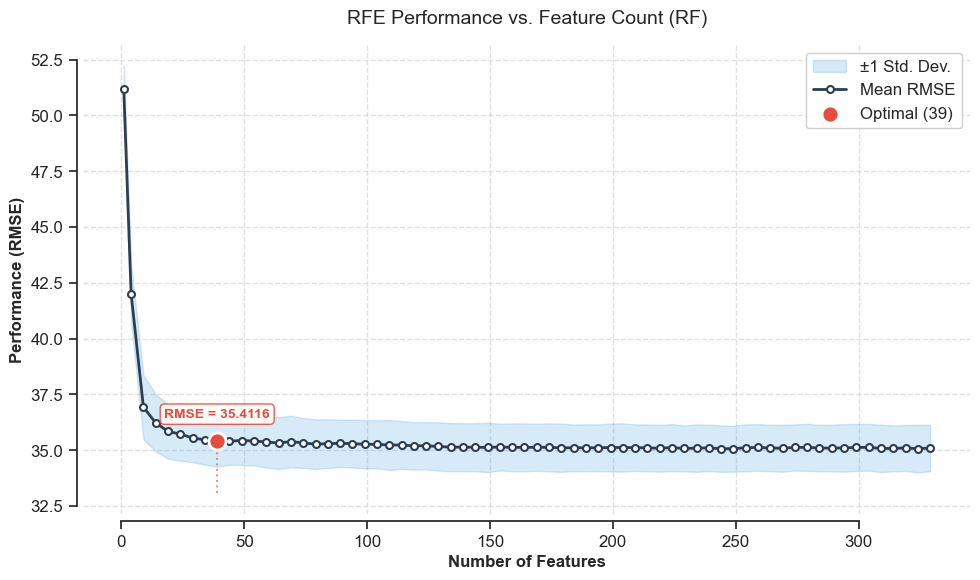

  Optimal Feature Set: 39 features
  Best RMSE: 35.4116

Running feature engineering workflow with RF model on H data
Number of samples: 615, Number of features: 388
Total number of features: 384

Variance threshold feature selection: variance_threshold=0.01
Original features: 384
Removed features: 64
Remaining features: 320

RFE feature selection: model=RF, tolerance=0.01, n_features_to_select=1, step=5


RFE Feature Selection:   2%|▏         | 1/64 iteration

Iteration 0/64 | Features: 315 | RMSE: 27.8797 ± 5.8510 | Removed: [MACCS_165, MACCS_18, MACCS_44, MACCS_67, RDKit_fr_sulfide]


RFE Feature Selection:  17%|█▋        | 11/64 iteration

Iteration 10/64 | Features: 265 | RMSE: 28.1070 ± 5.8860 | Removed: [MACCS_139, MACCS_66, MACCS_71, RDKit_NumSaturatedRings, RDKit_fr_imide]


...

Iteration 50/64 | Features: 65 | RMSE: 27.9213 ± 5.7504 | Removed: [RDKit_EState_VSA1, RDKit_Kappa2, RDKit_MaxAbsEStateIndex, RDKit_MaxEStateIndex, RDKit_fr_Ar_COO]


RFE Feature Selection:  95%|█████████▌| 61/64 iteration

Iteration 60/64 | Features: 15 | RMSE: 26.7969 ± 5.7837 | Removed: [RDKit_BCUT2D_MWHI, RDKit_Kappa3, RDKit_PEOE_VSA7, RDKit_SlogP_VSA2, RDKit_VSA_EState2]


RFE Feature Selection: 100%|██████████| 64/64 iteration


Global best RMSE: 26.5963
Threshold (1.0% tolerance): 26.8623

✓ RFE Feature Selection Complete (Parsimonious)
  Selected number of features: 5
  Selected RMSE: 26.8525
  Best features (Top 5): ['RDKit_BCUT2D_CHGLO', 'RDKit_FpDensityMorgan3', 'RDKit_BCUT2D_MRHI', 'RDKit_SlogP_VSA8', 'RDKit_fr_allylic_oxid']



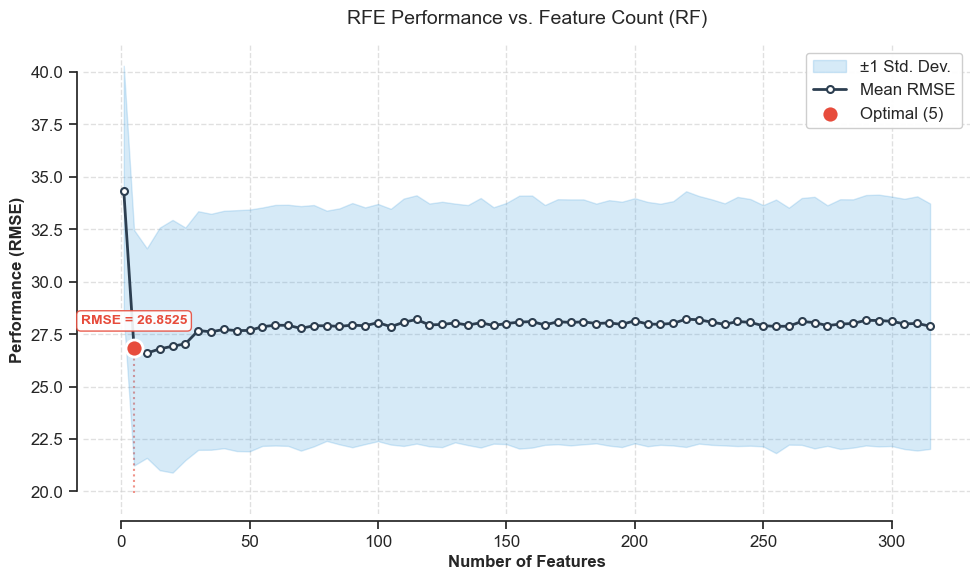

  Optimal Feature Set: 5 features
  Best RMSE: 26.8525

Running feature engineering workflow with RF model on All data
Number of samples: 12054, Number of features: 388
Total number of features: 384

Variance threshold feature selection: variance_threshold=0.01
Original features: 384
Removed features: 51
Remaining features: 333

RFE feature selection: model=RF, tolerance=0.01, n_features_to_select=1, step=5


RFE Feature Selection:   1%|▏         | 1/67 iteration

Iteration 0/67 | Features: 328 | RMSE: 38.6053 ± 1.0205 | Removed: [MACCS_17, MACCS_55, MACCS_60, RDKit_EState_VSA11, RDKit_fr_sulfonamd]


RFE Feature Selection:  16%|█▋        | 11/67 iteration

Iteration 10/67 | Features: 278 | RMSE: 38.5718 ± 1.0279 | Removed: [MACCS_140, MACCS_146, MACCS_64, MACCS_66, RDKit_fr_priamide]


...

Iteration 50/67 | Features: 78 | RMSE: 38.9130 ± 0.9879 | Removed: [RDKit_Chi2n, RDKit_Chi3n, RDKit_NumHeteroatoms, RDKit_SlogP_VSA4, RDKit_VSA_EState10]


RFE Feature Selection:  91%|█████████ | 61/67 iteration

Iteration 60/67 | Features: 28 | RMSE: 39.3687 ± 0.8697 | Removed: [RDKit_BCUT2D_CHGLO, RDKit_BCUT2D_LOGPLOW, RDKit_HallKierAlpha, RDKit_MinAbsEStateIndex, RDKit_SlogP_VSA2]


RFE Feature Selection: 100%|██████████| 67/67 iteration



Global best RMSE: 38.5356
Threshold (1.0% tolerance): 38.9209

✓ RFE Feature Selection Complete (Parsimonious)
  Selected number of features: 58
  Selected RMSE: 38.9203
  Best features (Top 5): ['RDKit_TPSA', 'RDKit_BertzCT', 'RDKit_RingCount', 'RDKit_NumHDonors', 'RDKit_NHOHCount']



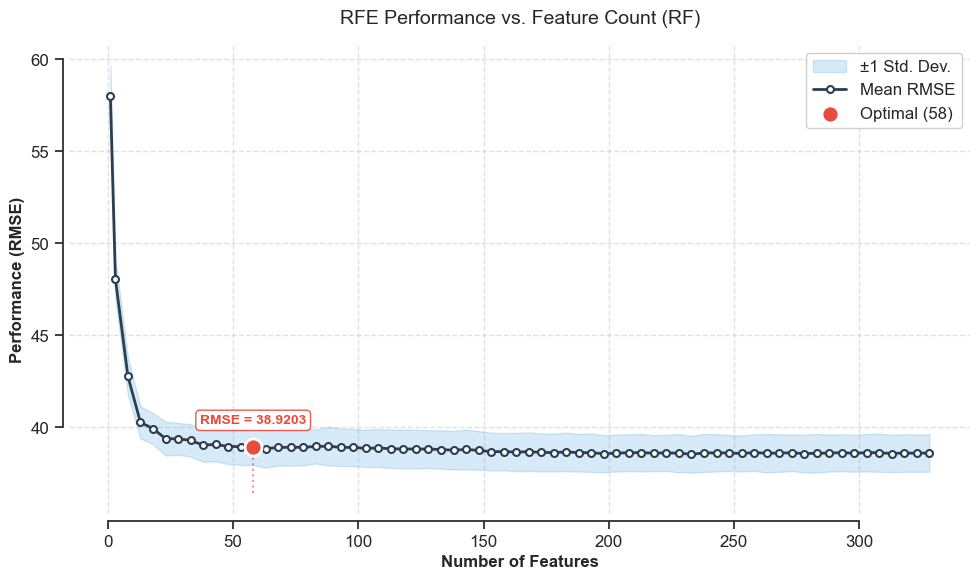

  Optimal Feature Set: 58 features
  Best RMSE: 38.9203



In [5]:
feature_engineering_dict = {}

for model_type in model_types:
    for data_type in data_types:

        data_train = df_all_feature[df_all_feature['Type'] == 'Train']
        if data_type == 'L':
            data_with_features_train = data_train[data_train[label] == 'L']
        elif data_type == 'H':
            data_with_features_train = data_train[data_train[label] == 'H']
        else:
            data_with_features_train = data_train

        print(f'Running feature engineering workflow with {model_type} model on {data_type} data')
        print(f'Number of samples: {data_with_features_train.shape[0]}, '
              f'Number of features: {data_with_features_train.shape[1]}')

        df_X_variance, RFE_results, df_X_RFE = feature_engineering_workflow(
            model_type, data_with_features_train
        )
        feature_engineering_dict[(model_type, data_type)] = RFE_results
        print()

with open('feature_engineering_dict_RF.pkl', 'wb') as f:
    pickle.dump(feature_engineering_dict, f)

## 2. Save Feature-Selected Datasets

In [6]:
# Load (in case of kernel restart)
with open('feature_engineering_dict_RF.pkl', 'rb') as f:
    feature_engineering_dict = pickle.load(f)

In [7]:
for model_type in model_types:
    for data_type in data_types:

        best_features = feature_engineering_dict[(model_type, data_type)]['best_features']
        print(f'Best features for {model_type} model - {data_type} data ({len(best_features)} features):')
        print(best_features)
        print()

        data_selected_features        = df_all_feature[non_feature_cols + best_features]
        data_selected_features_scaled = df_all_feature_scaled[non_feature_cols + best_features]

        data_selected_features.to_parquet(
            data_prefix + f'data_with_selected_features_{model_type}_{data_type}.parquet'
        )
        data_selected_features_scaled.to_parquet(
            data_prefix + f'data_with_selected_features_{model_type}_{data_type}_scaled.parquet'
        )

Best features for RF model - L data (39 features):
['RDKit_TPSA', 'RDKit_BertzCT', 'RDKit_RingCount', 'RDKit_NumHDonors', 'RDKit_NHOHCount', 'RDKit_BCUT2D_MRHI', 'RDKit_FractionCSP3', 'RDKit_SMR_VSA10', 'RDKit_FpDensityMorgan3', 'RDKit_BCUT2D_MRLOW', 'RDKit_VSA_EState3', 'RDKit_PEOE_VSA7', 'RDKit_Kappa3', 'RDKit_BCUT2D_LOGPHI', 'RDKit_VSA_EState2', 'RDKit_MolLogP', 'RDKit_BalabanJ', 'RDKit_VSA_EState4', 'MACCS_155', 'RDKit_qed', 'RDKit_BCUT2D_LOGPLOW', 'RDKit_AvgIpc', 'RDKit_BCUT2D_MWLOW', 'RDKit_VSA_EState6', 'RDKit_NumRotatableBonds', 'RDKit_MinEStateIndex', 'RDKit_MinPartialCharge', 'RDKit_MinAbsEStateIndex', 'RDKit_MaxEStateIndex', 'RDKit_Phi', 'RDKit_PEOE_VSA8', 'RDKit_BCUT2D_MWHI', 'RDKit_MaxPartialCharge', 'RDKit_BCUT2D_CHGLO', 'RDKit_MinAbsPartialCharge', 'RDKit_HallKierAlpha', 'RDKit_HeavyAtomMolWt', 'RDKit_MaxAbsPartialCharge', 'RDKit_PEOE_VSA9']

Best features for RF model - H data (5 features):
['RDKit_BCUT2D_CHGLO', 'RDKit_FpDensityMorgan3', 'RDKit_BCUT2D_MRHI', 'RDKit_Slo

## 3. Model Development (BayesSearchCV — mirrors LightGBM workflow)

In [8]:
def model_development(data, non_feature_cols, model_type, trials):

    X = data.drop(columns=non_feature_cols, errors='ignore')
    y = data['MP'].values
    strat_labels = data[label].values

    # Precompute folds stratified on label (not continuous MP)
    skf   = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    folds = list(skf.split(X, strat_labels))

    # Helper: run 10-fold CV for a given model instance
    def run_cv(model_instance):
        fold_rmses = []
        for train_idx, val_idx in folds:
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]
            model_instance.fit(X_train, y_train)
            preds = model_instance.predict(X_val)
            fold_rmses.append(np.sqrt(mean_squared_error(y_val, preds)))
        return fold_rmses

    # RF model + search space
    # NOTE: RF does not require scaled input; unscaled parquet is used below
    if model_type == 'RF':
        default_model = RandomForestRegressor(random_state=42, n_jobs=-1)
        base_model    = RandomForestRegressor(random_state=42, n_jobs=-1)
        search_space  = {
            'n_estimators':      Integer(20,  500),
            'max_depth':         Integer(3,    12),
            'min_samples_split': Integer(2,    10),
            'min_samples_leaf':  Integer(1,    10),
            'max_features':      Real(0.1, 1.0),
        }
    else:
        raise ValueError(f"model_type must be 'RF'; got '{model_type}'")

    # Trial 0: default hyperparameters
    trial_results = {}
    fold_rmses_0  = run_cv(default_model)
    mean_0 = float(np.mean(fold_rmses_0))
    std_0  = float(np.std(fold_rmses_0))
    trial_results[0] = {'fold_rmses': fold_rmses_0, 'mean_rmse': mean_0, 'std_rmse': std_0}
    print(f'Trial  0 (default) | mean RMSE: {mean_0:.4f} ± {std_0:.4f}')

    # Trials 1-N: BayesSearchCV
    opt = BayesSearchCV(
        base_model,
        search_space,
        n_iter=trials,
        cv=folds,
        scoring='neg_root_mean_squared_error',
        random_state=42,
        n_jobs=1,
        refit=True,
    )
    opt.fit(X, y)

    n_splits = len(folds)
    for i in range(trials):
        fold_rmses = [-opt.cv_results_[f'split{s}_test_score'][i] for s in range(n_splits)]
        mean_rmse  = float(np.mean(fold_rmses))
        std_rmse   = float(np.std(fold_rmses))
        trial_results[i + 1] = {
            'fold_rmses': fold_rmses,
            'mean_rmse':  mean_rmse,
            'std_rmse':   std_rmse,
        }
        print(f'Trial {i+1:>2d} | mean RMSE: {mean_rmse:.4f} ± {std_rmse:.4f}')

    return trial_results, opt.best_estimator_

In [9]:
for model in model_types:
    for data_type in data_types:

        # RF does not require feature scaling — load unscaled parquet
        data = pd.read_parquet(
            data_prefix + f'data_with_selected_features_{model}_{data_type}.parquet'
        )
        data = data[data['Type'] == 'Train'].reset_index(drop=True)

        if data_type != 'All':
            data = data[data[label] == data_type].reset_index(drop=True)

        print(f'\n=== Model: {model} ===')
        print(f'=== Data Type: {data_type} ===')
        print(f'Dataset shape: {data.shape} '
              f'(n_samples={data.shape[0]}, '
              f'n_features={data.shape[1] - len(non_feature_cols)})')

        trial_results, best_model = model_development(
            data, non_feature_cols, model_type=model, trials=20
        )

        with open(f'model_development_results_{model}_{data_type}.pkl', 'wb') as f:
            pickle.dump(trial_results, f)
        joblib.dump(best_model, f'best_model_{model}_{data_type}.joblib', compress=3)


=== Model: RF ===
=== Data Type: L ===
Dataset shape: (11439, 43) (n_samples=11439, n_features=39)
Trial  0 (default) | mean RMSE: 35.2626 ± 1.1455
Trial  1 | mean RMSE: 39.5121 ± 0.9175
Trial  2 | mean RMSE: 36.2986 ± 1.0545
Trial  3 | mean RMSE: 39.4808 ± 1.0027
Trial  4 | mean RMSE: 37.4130 ± 0.9386
Trial  5 | mean RMSE: 36.9532 ± 0.9514
Trial  6 | mean RMSE: 36.6822 ± 1.0354
Trial  7 | mean RMSE: 37.4299 ± 0.9858
Trial  8 | mean RMSE: 38.3352 ± 0.9759
Trial  9 | mean RMSE: 36.4829 ± 0.9926
Trial 10 | mean RMSE: 47.1664 ± 1.1599
Trial 11 | mean RMSE: 35.9929 ± 1.0857
Trial 12 | mean RMSE: 36.6086 ± 1.0774
Trial 13 | mean RMSE: 36.3901 ± 0.9669
Trial 14 | mean RMSE: 36.5776 ± 1.1411
Trial 15 | mean RMSE: 36.6086 ± 1.0774
Trial 16 | mean RMSE: 35.7871 ± 0.9821
Trial 17 | mean RMSE: 35.9536 ± 1.0423
Trial 18 | mean RMSE: 35.7785 ± 1.0224
Trial 19 | mean RMSE: 35.7931 ± 1.0422
Trial 20 | mean RMSE: 38.1088 ± 0.9363

=== Model: RF ===
=== Data Type: H ===
Dataset shape: (615, 9) (n_samp

/opt/anaconda3/envs/Surabie_S_clean_v2/lib/python3.11/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(12), 1.0, np.int64(1), np.int64(10), np.int64(500)] before, using random point [np.int64(7), 0.3677268625866803, np.int64(9), np.int64(3), np.int64(157)]
  warnings.warn(
/opt/anaconda3/envs/Surabie_S_clean_v2/lib/python3.11/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(12), 1.0, np.int64(1), np.int64(10), np.int64(500)] before, using random point [np.int64(6), 0.1419903431510362, np.int64(7), np.int64(2), np.int64(245)]
  warnings.warn(


Trial  1 | mean RMSE: 43.7389 ± 0.9782
Trial  2 | mean RMSE: 39.9629 ± 0.9899
Trial  3 | mean RMSE: 43.9396 ± 1.0096
Trial  4 | mean RMSE: 40.9793 ± 0.9613
Trial  5 | mean RMSE: 40.6432 ± 0.9831
Trial  6 | mean RMSE: 40.5144 ± 1.0146
Trial  7 | mean RMSE: 41.3415 ± 0.9701
Trial  8 | mean RMSE: 42.4785 ± 0.9996
Trial  9 | mean RMSE: 40.1180 ± 1.0377
Trial 10 | mean RMSE: 52.8537 ± 1.1255
Trial 11 | mean RMSE: 39.6690 ± 1.0737
Trial 12 | mean RMSE: 40.3123 ± 1.0840
Trial 13 | mean RMSE: 40.5033 ± 0.9077
Trial 14 | mean RMSE: 40.4569 ± 0.9054
Trial 15 | mean RMSE: 40.5547 ± 1.0640
Trial 16 | mean RMSE: 40.4984 ± 0.8942
Trial 17 | mean RMSE: 43.9522 ± 0.9753
Trial 18 | mean RMSE: 46.8004 ± 0.8902
Trial 19 | mean RMSE: 41.4340 ± 0.9083
Trial 20 | mean RMSE: 41.9235 ± 0.9736


## 4. Performance Plot

In [10]:
def plot_model_performance(model_development_results_dict):
    trials     = sorted(model_development_results_dict.keys())
    mean_rmses = np.array([model_development_results_dict[t]['mean_rmse'] for t in trials])
    std_rmses  = np.array([model_development_results_dict[t]['std_rmse']  for t in trials])

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(trials, mean_rmses, marker='o', linewidth=1.5, color='steelblue', label='Mean RMSE')
    ax.fill_between(trials,
                    mean_rmses - std_rmses,
                    mean_rmses + std_rmses,
                    alpha=0.25, color='steelblue', label='± 1 std')
    ax.axvline(x=0, color='grey', linestyle='--', linewidth=1, label='Default HP (trial 0)')

    best_trial = trials[int(np.argmin(mean_rmses))]
    best_rmse  = float(min(mean_rmses))
    ax.scatter([best_trial], [best_rmse], color='red', zorder=5,
               label=f'Best (trial {best_trial}, RMSE={best_rmse:.4f})')

    ax.set_xlabel('HP Tuning Iteration', fontsize=12)
    ax.set_ylabel('RMSE', fontsize=12)
    ax.set_title('Model Performance vs. HP Tuning Iteration', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


=== Performance plot for RF (L) ===


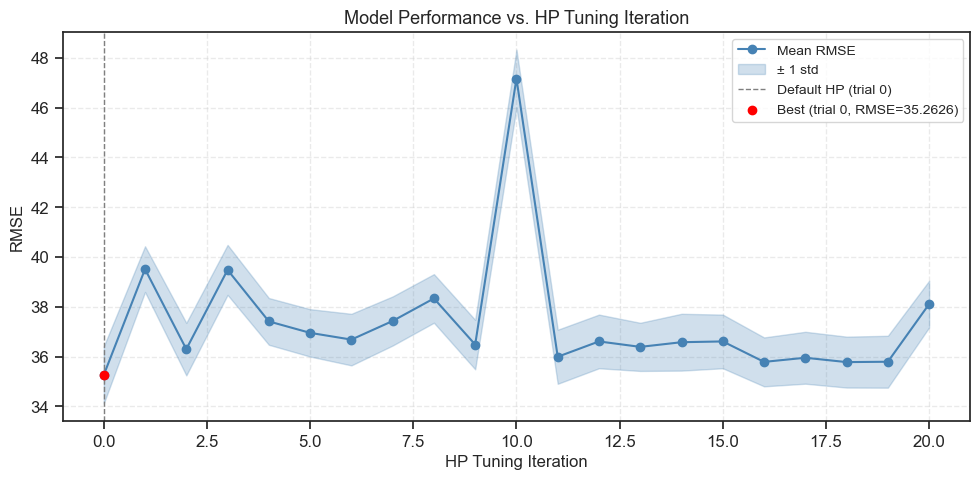


=== Performance plot for RF (H) ===


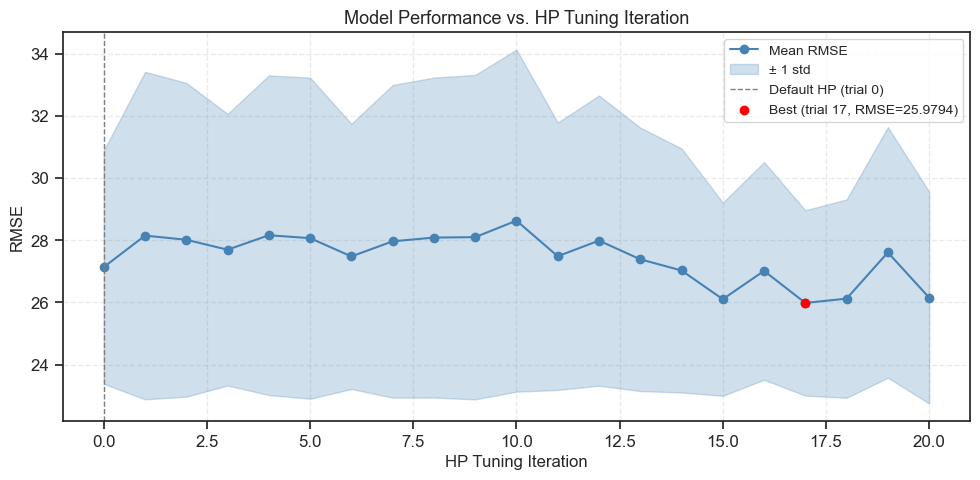


=== Performance plot for RF (All) ===


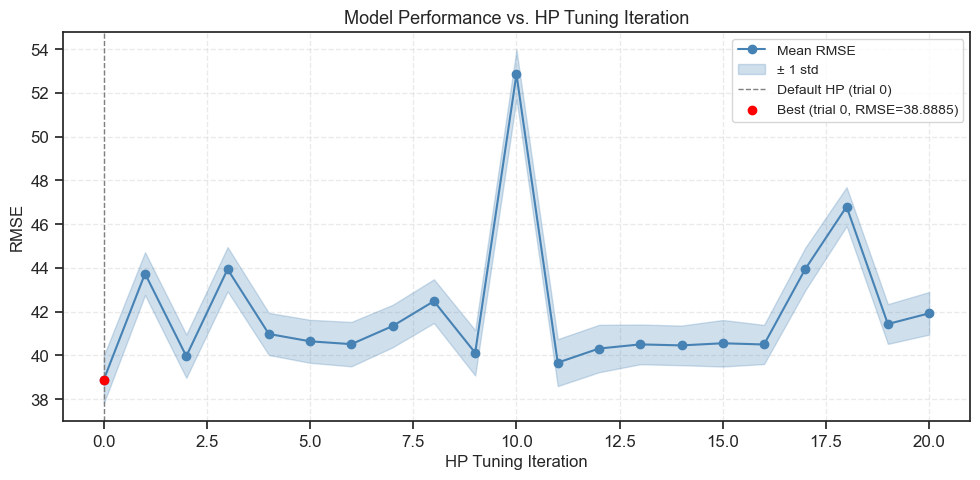

In [11]:
for model in model_types:
    for data_type in data_types:

        print(f'\n=== Performance plot for {model} ({data_type}) ===')

        with open(f'model_development_results_{model}_{data_type}.pkl', 'rb') as f:
            model_development_results = pickle.load(f)

        plot_model_performance(model_development_results)

## 5. Test Evaluation — Overall + Low-MP + High-MP

In [12]:
from sklearn.metrics import r2_score, mean_absolute_error

def evaluate_on_test(model, df, best_features, label_col=label):
    """Return metrics dict and predictions dataframe for a given split."""
    X    = df[best_features]
    y    = df['MP'].values
    pred = model.predict(X)

    out_df = pd.DataFrame({
        'SMILES'   : df['SMILES'].values,
        label_col  : df[label_col].values,
        'exp_MP'   : y,
        'pred_MP'  : pred,
        'error'    : pred - y,
        'abs_error': np.abs(pred - y),
    })

    def _m(sub):
        if len(sub) == 0:
            return {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan, 'n': 0}
        return {
            'RMSE': float(np.sqrt(mean_squared_error(sub['exp_MP'], sub['pred_MP']))),
            'MAE' : float(mean_absolute_error(sub['exp_MP'], sub['pred_MP'])),
            'R2'  : float(r2_score(sub['exp_MP'], sub['pred_MP'])),
            'n'   : len(sub),
        }

    cat = out_df[label_col].str.strip().str.upper()
    return out_df, _m(out_df), _m(out_df[cat == 'L']), _m(out_df[cat == 'H'])

In [13]:
all_test_metrics = []

for model in model_types:
    for data_type in data_types:

        best_features = feature_engineering_dict[(model, data_type)]['best_features']

        # RF: unscaled test data
        df_sel  = pd.read_parquet(
            data_prefix + f'data_with_selected_features_{model}_{data_type}.parquet'
        )
        df_test = df_sel[df_sel['Type'] == 'Test']

        best_model = joblib.load(f'best_model_{model}_{data_type}.joblib')

        out_df, m_all, m_L, m_H = evaluate_on_test(best_model, df_test, best_features)

        print(f'\n=== {model} | train={data_type} ===')
        print(f'  [Overall]  RMSE={m_all["RMSE"]:.4f}  MAE={m_all["MAE"]:.4f}  R2={m_all["R2"]:.4f}  n={m_all["n"]}')
        print(f'  [Low-MP]   RMSE={m_L["RMSE"]:.4f}  MAE={m_L["MAE"]:.4f}  R2={m_L["R2"]:.4f}  n={m_L["n"]}')
        print(f'  [High-MP]  RMSE={m_H["RMSE"]:.4f}  MAE={m_H["MAE"]:.4f}  R2={m_H["R2"]:.4f}  n={m_H["n"]}')

        out_df.to_csv(f'test_predictions_{model}_{data_type}.csv', index=False)

        all_test_metrics.append({
            'model': model, 'train_data': data_type,
            **{f'overall_{k}': v for k, v in m_all.items()},
            **{f'low_{k}': v    for k, v in m_L.items()},
            **{f'high_{k}': v   for k, v in m_H.items()},
        })

pd.DataFrame(all_test_metrics).to_csv('rf_test_metrics_summary.csv', index=False)
print('\n✅ Done.')
print(pd.DataFrame(all_test_metrics).to_string(index=False))


=== RF | train=L ===
  [Overall]  RMSE=42.2129  MAE=31.6273  R2=0.6493  n=5166
  [Low-MP]   RMSE=35.9244  MAE=28.0576  R2=0.6690  n=4903
  [High-MP]  RMSE=104.6053  MAE=98.1752  R2=-11.3698  n=263

=== RF | train=H ===
  [Overall]  RMSE=172.1630  MAE=156.9615  R2=-4.8341  n=5166
  [Low-MP]   RMSE=176.5998  MAE=164.2477  R2=-6.9999  n=4903
  [High-MP]  RMSE=28.1632  MAE=21.1265  R2=0.1034  n=263

=== RF | train=All ===
  [Overall]  RMSE=39.5589  MAE=30.1477  R2=0.6920  n=5166
  [Low-MP]   RMSE=36.1775  MAE=28.0522  R2=0.6643  n=4903
  [High-MP]  RMSE=79.6192  MAE=69.2129  R2=-6.1663  n=263

✅ Done.
model train_data  overall_RMSE  overall_MAE  overall_R2  overall_n   low_RMSE    low_MAE    low_R2  low_n  high_RMSE  high_MAE    high_R2  high_n
   RF          L     42.212918    31.627317    0.649262       5166  35.924415  28.057646  0.668959   4903 104.605348 98.175211 -11.369846     263
   RF          H    172.163027   156.961464   -4.834076       5166 176.599761 164.247739 -6.999872   4